# Oblate Spheroid Dimension Search

Finds oblate (ai, ci) dimensions that give a **scattering peak at 712–735 nm** with **FWHM ~ 104 nm**,
using the MLWA polarizability with JC gold data in n = (1.473 + 1.52) / 2 ≈ 1.497.

> **MLWA validity note:** The MLWA is perturbative in (ka)². For ai = 70 nm and n ≈ 1.5 at 700 nm,
> ka ≈ 1.0, which is outside the strictly valid regime. Use these results as a guide for dimensions,
> then validate with BEM for the best candidates.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os

MODEL_DIR = '/Users/clairewest/UIUC/Research/Codes/coupled_dipoles_updatedform'
sys.path.insert(0, MODEL_DIR)
os.chdir(MODEL_DIR)   # needed so dielectric_data() finds auJC_interp.tab

from coupled_dipole_model import Polarizability

c_light  = 2.998e10     # cm/s
hbar_eVs = 6.58212e-16  # eV·s
nback    = (1.473 + 1.52) / 2
print(f'nback = {nback:.4f}')

# Target experimental values
PEAK_MIN, PEAK_MAX = 712, 735   # nm
TARGET_FWHM        = 104        # nm
FWHM_TOL           = 25         # ± tolerance on FWHM [nm]

nback = 1.4965


In [2]:
# ── Load JC data ──────────────────────────────────────────────────────────────
sp = Polarizability(nback=nback)
w_all, eps_all = sp.dielectric_data()
wave_all = 1240 / (w_all * hbar_eVs)   # nm

# Restrict to visible–NIR window
mask  = (wave_all >= 450) & (wave_all <= 950)
w_use   = w_all[mask]
eps_use = eps_all[mask]
wav_use = wave_all[mask]   # nm, should be increasing

print(f'Wavelength range used: {wav_use[0]:.0f} – {wav_use[-1]:.0f} nm  ({len(wav_use)} points)')

Wavelength range used: 450 – 949 nm  (500 points)


In [3]:
# ── Helper functions ──────────────────────────────────────────────────────────

def oblate_scattering(ai_nm, ci_nm):
    """
    Compute in-plane scattering, extinction and absorption spectra for a single
    oblate spheroid using the MLWA polarizability.

    Parameters
    ----------
    ai_nm : float   semi-major axis [nm]
    ci_nm : float   semi-minor axis [nm]  (ci < ai for oblate)

    Returns
    -------
    Cext, Csca, Cabs : ndarray   cross sections [μm²], same length as wav_use
    """
    ai_cm = ai_nm * 1e-7
    ci_cm = ci_nm * 1e-7
    Cext = np.zeros(len(w_use))
    Csca = np.zeros(len(w_use))

    for i, (wi, epsi) in enumerate(zip(w_use, eps_use)):
        k   = wi / c_light * nback           # cm⁻¹
        alp = sp.alpha_spheroid_CS_MW(eps=epsi, w=wi, ai=ai_cm, ci=ci_cm, which='x')
        Cext[i] = 4 * np.pi * k * np.imag(alp)          * 1e8   # cm² → μm²
        Csca[i] = 8 * np.pi / 3 * k**4 * np.abs(alp)**2 * 1e8

    Cabs = Cext - Csca
    return Cext, Csca, Cabs


def peak_and_fwhm(wave, spectrum):
    """
    Return (peak_wavelength_nm, fwhm_nm) for a spectrum sampled on `wave` (nm).
    Uses linear interpolation to find the half-max crossings.
    Returns NaN for FWHM if either crossing is out of range.
    """
    idx  = np.argsort(wave)
    w, s = wave[idx], spectrum[idx]

    pk   = np.argmax(s)
    half = s[pk] / 2.0

    def interp_crossing(w_arr, s_arr):
        """First index where s_arr crosses below half, then interpolate."""
        below = np.where(s_arr < half)[0]
        if len(below) == 0:
            return np.nan
        j = below[0]
        if j == 0:
            return w_arr[0]
        # linear interpolation between j-1 and j
        frac = (half - s_arr[j-1]) / (s_arr[j] - s_arr[j-1])
        return w_arr[j-1] + frac * (w_arr[j] - w_arr[j-1])

    # Left side (reversed so we move away from peak toward shorter λ)
    w_left_cross = interp_crossing(w[:pk+1][::-1], s[:pk+1][::-1])
    # Right side
    w_right_cross = interp_crossing(w[pk:], s[pk:])

    fwhm = np.nan if np.isnan(w_left_cross) or np.isnan(w_right_cross) \
           else w_right_cross - w_left_cross
    return w[pk], fwhm

a=140 nm, c=35 nm  →  peak = 742.1 nm,  FWHM = 177.3 nm


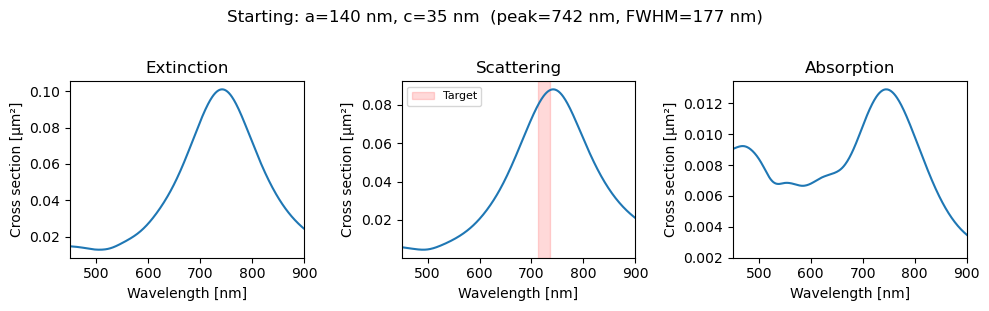

In [4]:
# ── Test: starting dimensions (experimental 140 × 35 nm disk) ─────────────────
ai0, ci0 = 70, 17.5   # semi-axes [nm]

Cext0, Csca0, Cabs0 = oblate_scattering(ai0, ci0)
pk0, fw0 = peak_and_fwhm(wav_use, Csca0)
print(f'a={2*ai0:.0f} nm, c={2*ci0:.0f} nm  →  peak = {pk0:.1f} nm,  FWHM = {fw0:.1f} nm')

fig, axes = plt.subplots(1, 3, figsize=[10, 3])
for ax, spec, title in zip(axes, [Cext0, Csca0, Cabs0],
                            ['Extinction', 'Scattering', 'Absorption']):
    ax.plot(wav_use, spec)
    ax.set_xlabel('Wavelength [nm]')
    ax.set_ylabel('Cross section [μm²]')
    ax.set_title(title)
    ax.set_xlim([450, 900])
axes[1].axvspan(PEAK_MIN, PEAK_MAX, alpha=0.15, color='red', label='Target')
axes[1].legend(fontsize=8)
plt.suptitle(f'Starting: a={2*ai0:.0f} nm, c={2*ci0:.0f} nm  (peak={pk0:.0f} nm, FWHM={fw0:.0f} nm)',
             y=1.02)
plt.tight_layout()

In [5]:
# ── Grid search ───────────────────────────────────────────────────────────────
# Semi-axes in nm; full dimensions = 2×semi-axis
ai_vals = np.arange(40, 110, 5)    # 40–105 nm  → full diam 80–210 nm
ci_vals = np.arange(6,  32,  2)    # 6–30 nm    → full height 12–60 nm

n_ai, n_ci = len(ai_vals), len(ci_vals)
peak_map = np.full((n_ai, n_ci), np.nan)
fwhm_map = np.full((n_ai, n_ci), np.nan)

total = sum(1 for ai in ai_vals for ci in ci_vals if ci < ai)
done  = 0

for i, ai in enumerate(ai_vals):
    for j, ci in enumerate(ci_vals):
        if ci >= ai:
            continue
        _, Csca, _ = oblate_scattering(ai, ci)
        pk, fw = peak_and_fwhm(wav_use, Csca)
        peak_map[i, j] = pk
        fwhm_map[i, j] = fw
        done += 1
        if done % 30 == 0:
            print(f'  {done}/{total} done...')

print('Grid search complete.')

  30/182 done...
  60/182 done...
  90/182 done...
  120/182 done...
  150/182 done...
  180/182 done...
Grid search complete.


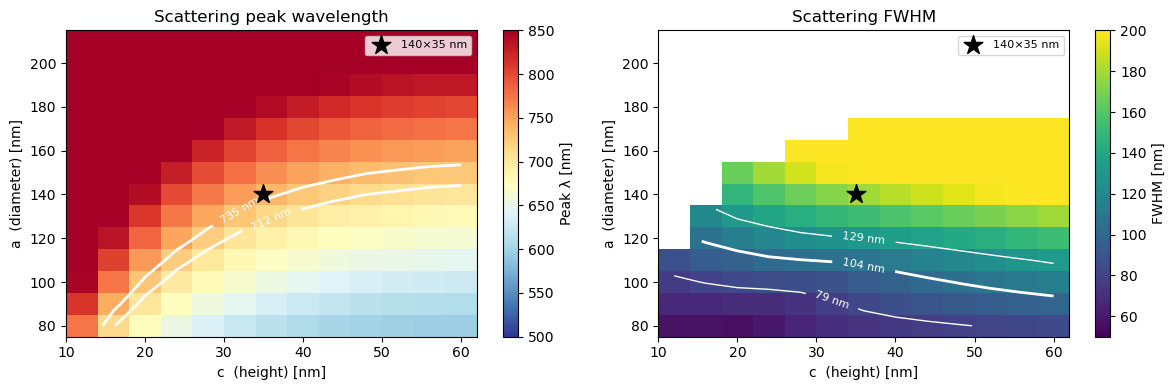

In [6]:
# ── 2-D parameter maps ────────────────────────────────────────────────────────
a_full = ai_vals * 2   # full diameter [nm]
c_full = ci_vals * 2   # full height   [nm]
C, A   = np.meshgrid(c_full, a_full)   # shape (n_ai, n_ci)

fig, axes = plt.subplots(1, 2, figsize=[12, 4])

# --- Peak wavelength map ---
ax = axes[0]
im = ax.pcolormesh(C, A, peak_map, cmap='RdYlBu_r', vmin=500, vmax=850,
                   shading='auto')
plt.colorbar(im, ax=ax, label='Peak λ [nm]')
# Contour lines for target window
try:
    cs = ax.contour(C, A, peak_map, levels=[PEAK_MIN, PEAK_MAX],
                    colors='white', linewidths=2)
    ax.clabel(cs, fmt='%d nm', fontsize=8)
except Exception:
    pass
ax.scatter([35], [140], marker='*', s=200, color='k', zorder=5, label='140×35 nm')
ax.set_xlabel('c  (height) [nm]');  ax.set_ylabel('a  (diameter) [nm]')
ax.set_title('Scattering peak wavelength')
ax.legend(fontsize=8)

# --- FWHM map ---
ax = axes[1]
im = ax.pcolormesh(C, A, fwhm_map, cmap='viridis', vmin=50, vmax=200,
                   shading='auto')
plt.colorbar(im, ax=ax, label='FWHM [nm]')
try:
    cs2 = ax.contour(C, A, fwhm_map,
                     levels=[TARGET_FWHM - FWHM_TOL, TARGET_FWHM, TARGET_FWHM + FWHM_TOL],
                     colors='white', linewidths=[1, 2, 1])
    ax.clabel(cs2, fmt='%d nm', fontsize=8)
except Exception:
    pass
ax.scatter([35], [140], marker='*', s=200, color='k', zorder=5, label='140×35 nm')
ax.set_xlabel('c  (height) [nm]');  ax.set_ylabel('a  (diameter) [nm]')
ax.set_title('Scattering FWHM')
ax.legend(fontsize=8)

plt.tight_layout()

In [7]:
# ── Find matching configurations ──────────────────────────────────────────────
matches = []
for i, ai in enumerate(ai_vals):
    for j, ci in enumerate(ci_vals):
        pk = peak_map[i, j]
        fw = fwhm_map[i, j]
        if np.isnan(pk) or np.isnan(fw):
            continue
        if PEAK_MIN <= pk <= PEAK_MAX and abs(fw - TARGET_FWHM) <= FWHM_TOL:
            matches.append(dict(ai=ai, ci=ci, a=2*ai, c=2*ci, peak=pk, fwhm=fw))

# Sort by closeness to target FWHM, then by peak centre
matches.sort(key=lambda r: abs(r['fwhm'] - TARGET_FWHM) + abs(r['peak'] - (PEAK_MIN+PEAK_MAX)/2))

print(f"{'a [nm]':>8} {'c [nm]':>8} {'Peak [nm]':>12} {'FWHM [nm]':>12}")
print('-' * 44)
for m in matches:
    print(f"{m['a']:>8.0f} {m['c']:>8.0f} {m['peak']:>12.1f} {m['fwhm']:>12.1f}")

if not matches:
    print('No exact matches — showing 5 closest by peak wavelength:')
    # Show closest by peak wavelength centre
    all_res = []
    for i, ai in enumerate(ai_vals):
        for j, ci in enumerate(ci_vals):
            pk, fw = peak_map[i,j], fwhm_map[i,j]
            if not np.isnan(pk):
                all_res.append(dict(ai=ai, ci=ci, a=2*ai, c=2*ci, peak=pk, fwhm=fw))
    all_res.sort(key=lambda r: abs(r['peak'] - (PEAK_MIN+PEAK_MAX)/2))
    for m in all_res[:5]:
        print(f"  a={m['a']:.0f}, c={m['c']:.0f}:  peak={m['peak']:.1f} nm,  FWHM={m['fwhm']:.1f} nm")

  a [nm]   c [nm]    Peak [nm]    FWHM [nm]
--------------------------------------------
     110       24        723.1        101.4
     120       28        724.1        123.7
     100       20        729.1         82.6


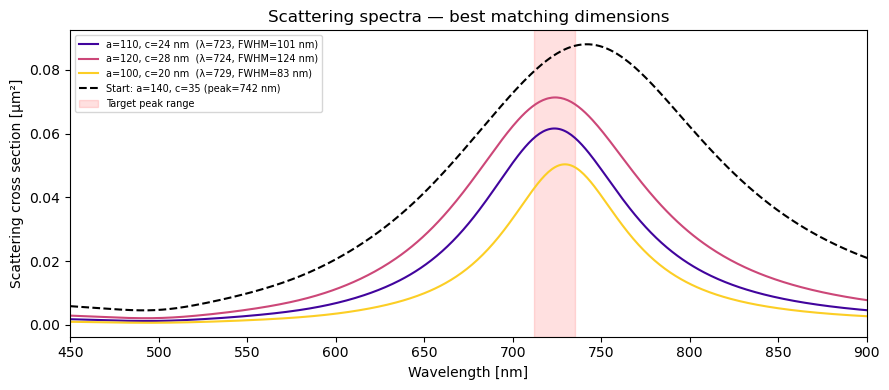

In [8]:
# ── Plot spectra of best candidates ──────────────────────────────────────────
candidates = matches[:8] if matches else []

if not candidates:
    # Fall back: 5 closest by peak wavelength
    all_res = []
    for i, ai in enumerate(ai_vals):
        for j, ci in enumerate(ci_vals):
            pk, fw = peak_map[i,j], fwhm_map[i,j]
            if not np.isnan(pk):
                all_res.append(dict(ai=ai, ci=ci, a=2*ai, c=2*ci, peak=pk, fwhm=fw))
    all_res.sort(key=lambda r: abs(r['peak'] - (PEAK_MIN+PEAK_MAX)/2))
    candidates = all_res[:5]

fig, ax = plt.subplots(figsize=[9, 4])
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(candidates)))

for m, col in zip(candidates, colors):
    _, Csca, _ = oblate_scattering(m['ai'], m['ci'])
    ax.plot(wav_use, Csca, color=col,
            label=f"a={m['a']:.0f}, c={m['c']:.0f} nm  "
                  f"(λ={m['peak']:.0f}, FWHM={m['fwhm']:.0f} nm)")

# Also show starting geometry
ax.plot(wav_use, Csca0, 'k--', lw=1.5, label=f'Start: a=140, c=35 (peak={pk0:.0f} nm)')

ax.axvspan(PEAK_MIN, PEAK_MAX, alpha=0.12, color='red', label='Target peak range')
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Scattering cross section [μm²]')
ax.set_title('Scattering spectra — best matching dimensions')
ax.set_xlim([450, 900])
ax.legend(fontsize=7, loc='upper left', ncol=1)
plt.tight_layout()